# Week 3 — Prediction Model (Turbo.az Cars, Price Regression)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "data/cars.csv"


## 1. Load data

In [18]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(df_raw.shape)
df_raw.head()


(653721, 56)


,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,...,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.0,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,...,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,...,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.0,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,...,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,...,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-957a4c43c25d,/autos/8674773-toyota-prius,2024-09-13 20:32:19.751157+00,Toyota Prius,10500.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,...,Variator,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,354 000 km,Ön,Bakı,82078856-0d07-4a0d-8123-69c2e5002e07,/autos/8674773-toyota-prius,Arxa görüntü kamerası


## 2. Standardize columns

In [19]:
exact_map = {
    'price_x': 'price_x',
    'price_y': 'price_y',
    'currency_x': 'currency_x',
    'currency_y': 'currency_y',
    'city': 'city_en',
    'Şəhər': 'city_az',
    'vip': 'vip',
    'featured': 'featured',
    'barter': 'barter',
    'loan': 'loan',
    'salon': 'salon',
    'Ban növü': 'body_type',
    'Buraxılış ili': 'year',
    'Marka': 'brand',
    'Model': 'model',
    'Mühərrik': 'engine',
    'Qəzalı': 'accident',
    'Rəng': 'color',
    'Sahiblər': 'owners_count',
    'Sürətlər qutusu Vəziyyəti': 'transmission',
    'Yeni': 'is_new',
    'Yerlərin sayı': 'seats',
    'Yürüş': 'mileage',
    'Ötürücü': 'drivetrain',
}

fallback_keywords = {
    'body_type': ['ban', 'body'],
    'transmission': ['suretl', 'sürətl', 'transmission', 'gearbox'],
    'drivetrain': ['oturuc', 'ötürüc', 'drive'],
    'brand': ['marka', 'brand'],
    'model': ['model'],
    'year': ['buraxil', 'buraxıl', 'year'],
    'mileage': ['yurus', 'yürüş', 'mileage'],
    'color': ['reng', 'rəng', 'color'],
    'is_new': ['yeni', 'new'],
    'engine': ['muherrik', 'mühərrik', 'engine'],
    'owners_count': ['sahibl', 'owner'],
    'seats': ['yerl', 'seat'],
}

present = {k: v for k, v in exact_map.items() if k in df_raw.columns}
df = df_raw.rename(columns=present)[list(present.values())].copy()

std_names_have = set(present.values())
cols_lower = {c: c.lower() for c in df_raw.columns}

for std_name, keywords in fallback_keywords.items():
    if std_name in std_names_have:
        continue
    match = None
    for raw_col, low in cols_lower.items():
        if any(k in low for k in keywords):
            match = raw_col
            break
    if match is not None:
        df[std_name] = df_raw[match]
        std_names_have.add(std_name)
        print(f"Fallback match: '{std_name}' <- '{match}'")
    else:
        print(f"WARNING: could not resolve column for '{std_name}'")

if 'city_en' in df.columns or 'city_az' in df.columns:
    df['city'] = df.get('city_en', pd.Series(np.nan, index=df.index)).fillna(
        df.get('city_az', pd.Series(np.nan, index=df.index)))

print(list(df.columns))
df.head()


Fallback match: 'transmission' <- 'Sürətlər qutusu'
['price_x', 'price_y', 'currency_x', 'currency_y', 'city_en', 'city_az', 'vip', 'featured', 'barter', 'loan', 'salon', 'body_type', 'year', 'brand', 'model', 'engine', 'accident', 'color', 'owners_count', 'is_new', 'seats', 'mileage', 'drivetrain', 'transmission', 'city']


,price_x,price_y,currency_x,currency_y,city_en,city_az,vip,featured,barter,loan,...,engine,accident,color,owners_count,is_new,seats,mileage,drivetrain,transmission,city
0,15000.0,15000.0,AZN,AZN,bakı,Bakı,NaN,NaN,NaN,NaN,...,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Xeyr,5,270 000 km,Ön,Mexaniki,bakı
1,23700.0,23700.0,AZN,AZN,bakı,Bakı,vipped-icon,featured-icon,NaN,NaN,...,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Bəli,5,0 km,Tam,Mexaniki,bakı
2,35600.0,35600.0,$,USD,bakı,Bakı,vipped-icon,featured-icon,NaN,NaN,...,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Xeyr,8+,164 750 km,Tam,Avtomat,bakı
3,26700.0,26700.0,AZN,AZN,bakı,Bakı,vipped-icon,NaN,NaN,NaN,...,2.0 L/150 a.g./Benzin,NaN,Boz,1,Xeyr,NaN,126 000 km,Ön,Avtomat,bakı
4,10500.0,10500.0,AZN,AZN,bakı,Bakı,vipped-icon,NaN,NaN,NaN,...,1.5 L/76 a.g./Hibrid,NaN,Qırmızı,2,Xeyr,5,354 000 km,Ön,Variator,bakı


## 3. Build target: price_usd

In [20]:
AZN_TO_USD = 1 / 1.70

def to_usd(price, currency):
    if pd.isna(price) or pd.isna(currency):
        return np.nan
    currency = str(currency).strip().upper()
    if currency in ('USD', '$'):
        return price
    if currency in ('AZN', 'MAN', 'AZ'):
        return price * AZN_TO_USD
    return np.nan

df['price_usd'] = [
    to_usd(px, cx) if pd.notna(to_usd(px, cx)) else to_usd(py, cy)
    for px, cx, py, cy in zip(
        df.get('price_x', pd.Series(np.nan, index=df.index)),
        df.get('currency_x', pd.Series(np.nan, index=df.index)),
        df.get('price_y', pd.Series(np.nan, index=df.index)),
        df.get('currency_y', pd.Series(np.nan, index=df.index)),
    )
]

print(df['price_usd'].notna().sum(), "/", len(df))


647835 / 653721


## 4. Select features and clean

In [21]:
for col in ['mileage', 'year', 'owners_count', 'seats']:
    if col in df.columns and df[col].dtype == object:
        df[col] = (df[col].astype(str)
                   .str.replace(r'[^0-9.\-]', '', regex=True)
                   .replace('', np.nan)
                   .astype(float))

if 'engine' in df.columns:
    df['engine_volume'] = (df['engine'].astype(str)
                            .str.extract(r'(\d+\.\d+|\d+)')[0]
                            .astype(float))

numeric_features = [c for c in ['year', 'mileage', 'engine_volume', 'owners_count', 'seats'] if c in df.columns]
categorical_features = [c for c in ['brand', 'body_type', 'transmission', 'drivetrain', 'color', 'city', 'is_new'] if c in df.columns]

required = ['price_usd'] + numeric_features + categorical_features
df = df.dropna(subset=['price_usd'])

Q1, Q3 = df['price_usd'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df = df[(df['price_usd'] >= Q1 - 1.5*IQR) & (df['price_usd'] <= Q3 + 1.5*IQR)]

df = df.dropna(subset=['price_usd'])
print(df.shape)
print("numeric:", numeric_features)
print("categorical:", categorical_features)


(596116, 27)
numeric: ['year', 'mileage', 'engine_volume', 'owners_count', 'seats']
categorical: ['brand', 'body_type', 'transmission', 'drivetrain', 'color', 'city', 'is_new']


## Checkpoint 1 — Train/test split before preprocessing

In [22]:
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str).str.replace(r'[^0-9.\-]', '', regex=True).replace('', np.nan),
        errors='coerce'
    )

for col in numeric_features:
    df[col] = clean_numeric(df[col])

X = df[numeric_features + categorical_features]
y = df['price_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(X_train[numeric_features].dtypes)


(476892, 12) (119224, 12)
year               int64
mileage            int64
engine_volume    float64
owners_count     float64
seats            float64
dtype: object


## Checkpoint 2 — Preprocessing pipeline

In [23]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


## Checkpoint 3 — Train at least 2 models

In [25]:
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
    n_estimators=50,
    max_depth=15,        # ağacların dərinliyini məhdudlaşdırır
    random_state=42,
    n_jobs=-1
))
])

model_lr.fit(X_train, y_train)
model_rf.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['year','mileage','engine_volume',...,'color','city','is_new']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis co

## Checkpoint 4 — Right metrics for regression

In [26]:
def evaluate(model, X_test, y_test, name):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name}: RMSE={rmse:.2f}  MAE={mae:.2f}  R2={r2:.4f}")
    return rmse, mae, r2

evaluate(model_lr, X_test, y_test, "Linear Regression")
evaluate(model_rf, X_test, y_test, "Random Forest")


Linear Regression: RMSE=5699.09  MAE=4080.84  R2=0.7408
Random Forest: RMSE=2537.21  MAE=1543.97  R2=0.9486


(np.float64(2537.2096811051065), 1543.9740662504691, 0.9486172121301164)

## Checkpoint 5 — Cross-validation

In [27]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_lr = cross_val_score(model_lr, X, y, cv=kf, scoring='neg_root_mean_squared_error')
cv_scores_rf = cross_val_score(model_rf, X, y, cv=kf, scoring='neg_root_mean_squared_error')

print("Linear Regression CV RMSE:", -cv_scores_lr.mean(), "+/-", cv_scores_lr.std())
print("Random Forest CV RMSE:", -cv_scores_rf.mean(), "+/-", cv_scores_rf.std())


Linear Regression CV RMSE: 5709.751367442921 +/- 14.152964780439143
Random Forest CV RMSE: 2546.4694838900564 +/- 19.240852547081076


## Checkpoint 6 — Feature importance

In [28]:
ohe = model_rf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_feature_names

importances = model_rf.named_steps['regressor'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

feat_imp.head(15)


year                                 0.474599
engine_volume                        0.216659
drivetrain_Ön                        0.144597
transmission_Mexaniki                0.034829
mileage                              0.021183
body_type_Offroader / SUV, 5 qapı    0.009495
brand_Mercedes                       0.009029
body_type_Sedan                      0.007421
brand_Land Rover                     0.005824
seats                                0.005143
brand_Hyundai                        0.005044
brand_Toyota                         0.004778
brand_BMW                            0.004056
drivetrain_Arxa                      0.002876
brand_Audi                           0.002838
dtype: float64

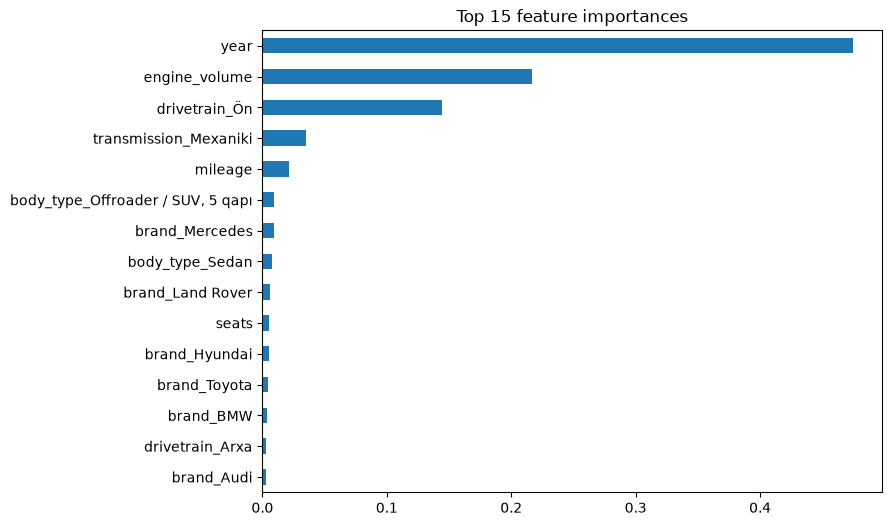

In [29]:
plt.figure(figsize=(8, 6))
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 feature importances")
plt.show()


**Interpretation (simple):**

The top features show which car details matter most for price. Usually year and mileage are strong, because newer cars with less mileage cost more. Brand and body type also matter, because some brands and body types are more expensive in general. This helps us understand what buyers pay for, not just predict the price.
